In [120]:
%reset -f

import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoLocator
from matplotlib.transforms import ScaledTranslation
plt.rcParams.update({'font.size': 16})
import seaborn as sns
import matplotlib.dates as mdates
import nrarfcn as nr

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

### Map plotting imports
import geopandas as gpd
from bokeh.plotting import figure, show#, output_notebook
# output_notebook()
from bokeh.models import ColumnDataSource, LinearColorMapper, ColorBar, HoverTool, WheelZoomTool, WMTSTileSource, Arrow, NormalHead
from bokeh.palettes import Viridis256, Bokeh
from bokeh.io import output_file
from bokeh.transform import factor_cmap
import random
from bokeh.io import output_notebook
output_notebook()

Loading BokehJS ...

In [121]:
def plot_geo_scatter_map(df, value_col, title="Geo Map", colorbar_title="Value", unit="", value_range=[-140, -60], dir_arrow=False):

    if 'latitude' in df.columns:
        df.rename(columns={'latitude': 'Latitude'}, inplace=True)
    if 'longitude' in df.columns:
        df.rename(columns={'longitude': 'Longitude'}, inplace=True)

    # Create GeoDataFrame and project to Web Mercator
    gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df['Longitude'], df['Latitude']), crs="EPSG:4326").to_crs("EPSG:3857")
    gdf['x'], gdf['y'] = gdf.geometry.x, gdf.geometry.y

    # Setup Bokeh figure
    p = figure(
        title=title, width=800, height=500,
        x_axis_type="mercator", y_axis_type="mercator",
        tools="pan,reset,save",
        x_range=(gdf['x'].min()-100, gdf['x'].max()+100),
        y_range=(gdf['y'].min()-100, gdf['y'].max()+100)
    )
    p.add_tools(WheelZoomTool(zoom_on_axis=False))
    p.add_tile(WMTSTileSource(
        url='https://cartodb-basemaps-4.global.ssl.fastly.net/light_all/{Z}/{X}/{Y}.png',
        attribution="© CartoDB contributors")
    )

    # Color mapping and data source
    # color_mapper = LinearColorMapper(palette=Bokeh[8], low=gdf[value_col].min(), high=gdf[value_col].max())
    color_mapper = LinearColorMapper(palette=Bokeh[8], low=value_range[0], high=value_range[1])
    # color_mapper = LinearColorMapper(palette=Viridis256, low=-160, high=-40)
    source = ColumnDataSource(gdf[['x', 'y', value_col, 'Latitude', 'Longitude']])

    # Scatter points
    p.scatter(
        x='x', y='y', size=5, source=source,
        fill_color={'field': value_col, 'transform': color_mapper},
        line_color=None, fill_alpha=0.7
    )

    # Walking-direction arrows adjacent to the measurements
    if dir_arrow and len(gdf) > 1:
        arrow_step = max(1, len(gdf) // 20)
        map_width = gdf['x'].max() - gdf['x'].min()
        map_height = gdf['y'].max() - gdf['y'].min()
        arrow_offset = max(map_width, map_height) * 0.05  # distance from measurements in Web Mercator meters

        for start_index in range(0, len(gdf) - 1, arrow_step):
            end_index = min(start_index + arrow_step, len(gdf) - 1)

            x_start = gdf['x'].iloc[start_index]
            y_start = gdf['y'].iloc[start_index]
            x_end = gdf['x'].iloc[end_index]
            y_end = gdf['y'].iloc[end_index]

            delta_x = x_end - x_start
            delta_y = y_end - y_start
            segment_length = np.sqrt(delta_x**2 + delta_y**2)

            if segment_length == 0:
                continue

            offset_x = -delta_y / segment_length * arrow_offset
            offset_y = delta_x / segment_length * arrow_offset

            p.add_layout(Arrow(
                end=NormalHead(size=8, fill_color="black", line_color="black"),
                x_start=x_start + offset_x, y_start=y_start + offset_y,
                x_end=x_end + offset_x, y_end=y_end + offset_y,
                line_color="black", line_width=1.5
            ))

    # Color bar and hover
    p.add_layout(ColorBar(color_mapper=color_mapper, label_standoff=12, location=(0,0), title=colorbar_title), 'right')
    p.add_tools(HoverTool(tooltips=[
        ("Lat/Lon", "@{Latitude}, @{Longitude}"),
        (value_col, f"@{{{value_col}}} {unit}")
    ]))

    ### Adding a red cross
    # cross_gdf = gpd.GeoDataFrame(geometry=gpd.points_from_xy([-86.229485], [41.695861]), crs="EPSG:4326").to_crs("EPSG:3857")
    # p.scatter(x=cross_gdf.geometry.x[0], y=cross_gdf.geometry.y[0], size=15, marker="cross", color='red', line_width=3)

    p.toolbar.active_drag = None
    p.toolbar.active_inspect = None

    # output_file("bokeh_plot.html")
    show(p)

In [122]:
def load_csv(name):
    # This enables loading CSVs and pd.to_datetime simultaneously
    return pd.read_csv(f"2026q3-ndCbrsCbandInterference/_data/{name}.csv", parse_dates=['Time'])

# lteRadio = load_csv('lte_radio')
# ltePdsch = load_csv('lte_pdsch')
# ltePusch = load_csv('lte_pusch')
nrRadio = load_csv('nr_radio')
# nrRadioBeam = load_csv('nr_radio_beam')
nrPdsch = load_csv('nr_pdsch')
nrPusch = load_csv('nr_pusch')

In [123]:
# mask_collection = {
#     'C_000', 'C_001', 'C_002', 'C_003', 'C_004', 'C_005', 'C_006', 'C_007', 'C_008', 'C_009', 'C_010', 'C_011', 'C_012', 'C_013', 'C_014', 'C_015', 'C_016', 'C_017', 'C_018', 'C_019', 'C_020', 'C_021', 
#     'V_000', 'V_001', 'V_002', 'V_003', 'V_004', 'V_005', 'V_006', 'V_007', 'V_008', 'V_009', 'V_010', 'V_011', 'V_012', 'V_013', 'V_014', 'V_015', 'V_016', 'V_017', 'V_018', 'V_019', 'V_020', 'V_021'
#     }

# dfNrRadio_1 = nrRadio[nrRadio['Collection'].isin(mask_collection)].copy()
# # dfNrRadioBeam_1 = nrRadioBeam[nrRadioBeam['Collection'].isin(mask_collection)].copy()
# dfNrPdsch_1 = nrPdsch[nrPdsch['Collection'].isin(mask_collection)].copy()
# dfNrPusch_1 = nrPusch[nrPusch['Collection'].isin(mask_collection)].copy()

# LocationA

In [124]:
collections = [f'{prefix}_{number:03d}' for prefix in ['C', 'V'] for number in range(4, 13)]
plot_geo_scatter_map(nrRadio[nrRadio['Collection'].isin(collections)].dropna(subset=['Latitude', 'Longitude', 'SS-RSRP']), value_col='SS-RSRP', title="Collection 004-012", colorbar_title="SS-RSRP", unit="dBm", value_range=[-120, -50])

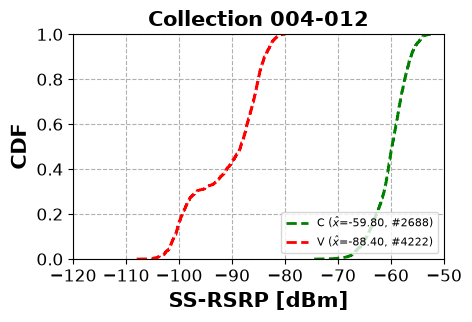

In [125]:
plt.rcParams["text.usetex"] = False

collection_numbers = [f'{number:03d}' for number in range(4, 13)]

fig, ax = plt.subplots(figsize=(5, 3.5))

for prefix, color in [('C', 'green'), ('V', 'red')]:
    collections = [f'{prefix}_{number}' for number in collection_numbers]
    df_temp = nrRadio.loc[nrRadio['Collection'].isin(collections), 'SS-RSRP'].dropna().sort_values()

    ax.plot(
        df_temp, np.linspace(0, 1, df_temp.shape[0]),
        label=rf"{prefix} ($\hat{{x}}$={df_temp.median():.2f}, #{df_temp.shape[0]})",
        linewidth=2, linestyle="dashed", color=color
    )

ax.set_title(f"Collection {collection_numbers[0]}-{collection_numbers[-1]}", fontsize=15, fontweight="bold")
ax.set_xlabel("SS-RSRP [dBm]", fontsize=15, fontweight="bold")
ax.set_ylabel("CDF", fontsize=15, fontweight="bold")
ax.set_xlim(-120, -50)
ax.set_ylim(0, 1)
ax.yaxis.set_minor_locator(AutoLocator())
ax.grid(True, linestyle="--", which="both", axis="both")
ax.tick_params(axis="both", labelsize=12)
ax.legend(fontsize=8, loc="lower right")

plt.tight_layout()
plt.show()

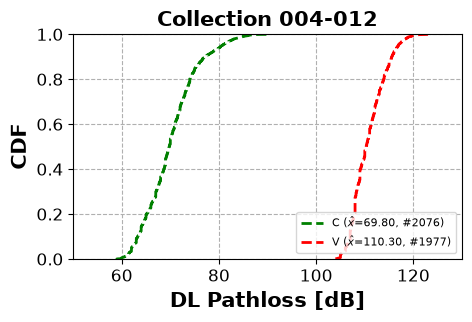

In [126]:
plt.rcParams["text.usetex"] = False

collection_numbers = [f'{number:03d}' for number in range(4, 13)]

fig, ax = plt.subplots(figsize=(5, 3.5))

for prefix, color in [('C', 'green'), ('V', 'red')]:
    collections = [f'{prefix}_{number}' for number in collection_numbers]
    df_temp = nrPusch.loc[nrPusch['Collection'].isin(collections), 'DL Pathloss'].dropna().sort_values()

    ax.plot(
        df_temp, np.linspace(0, 1, df_temp.shape[0]),
        label=rf"{prefix} ($\hat{{x}}$={df_temp.median():.2f}, #{df_temp.shape[0]})",
        linewidth=2, linestyle="dashed", color=color
    )

ax.set_title(f"Collection {collection_numbers[0]}-{collection_numbers[-1]}", fontsize=15, fontweight="bold")
ax.set_xlabel("DL Pathloss [dB]", fontsize=15, fontweight="bold")
ax.set_ylabel("CDF", fontsize=15, fontweight="bold")
ax.set_xlim(50, 130)
ax.set_ylim(0, 1)
ax.yaxis.set_minor_locator(AutoLocator())
ax.grid(True, linestyle="--", which="both", axis="both")
ax.tick_params(axis="both", labelsize=12)
ax.legend(fontsize=8, loc="lower right")

plt.tight_layout()
plt.show()

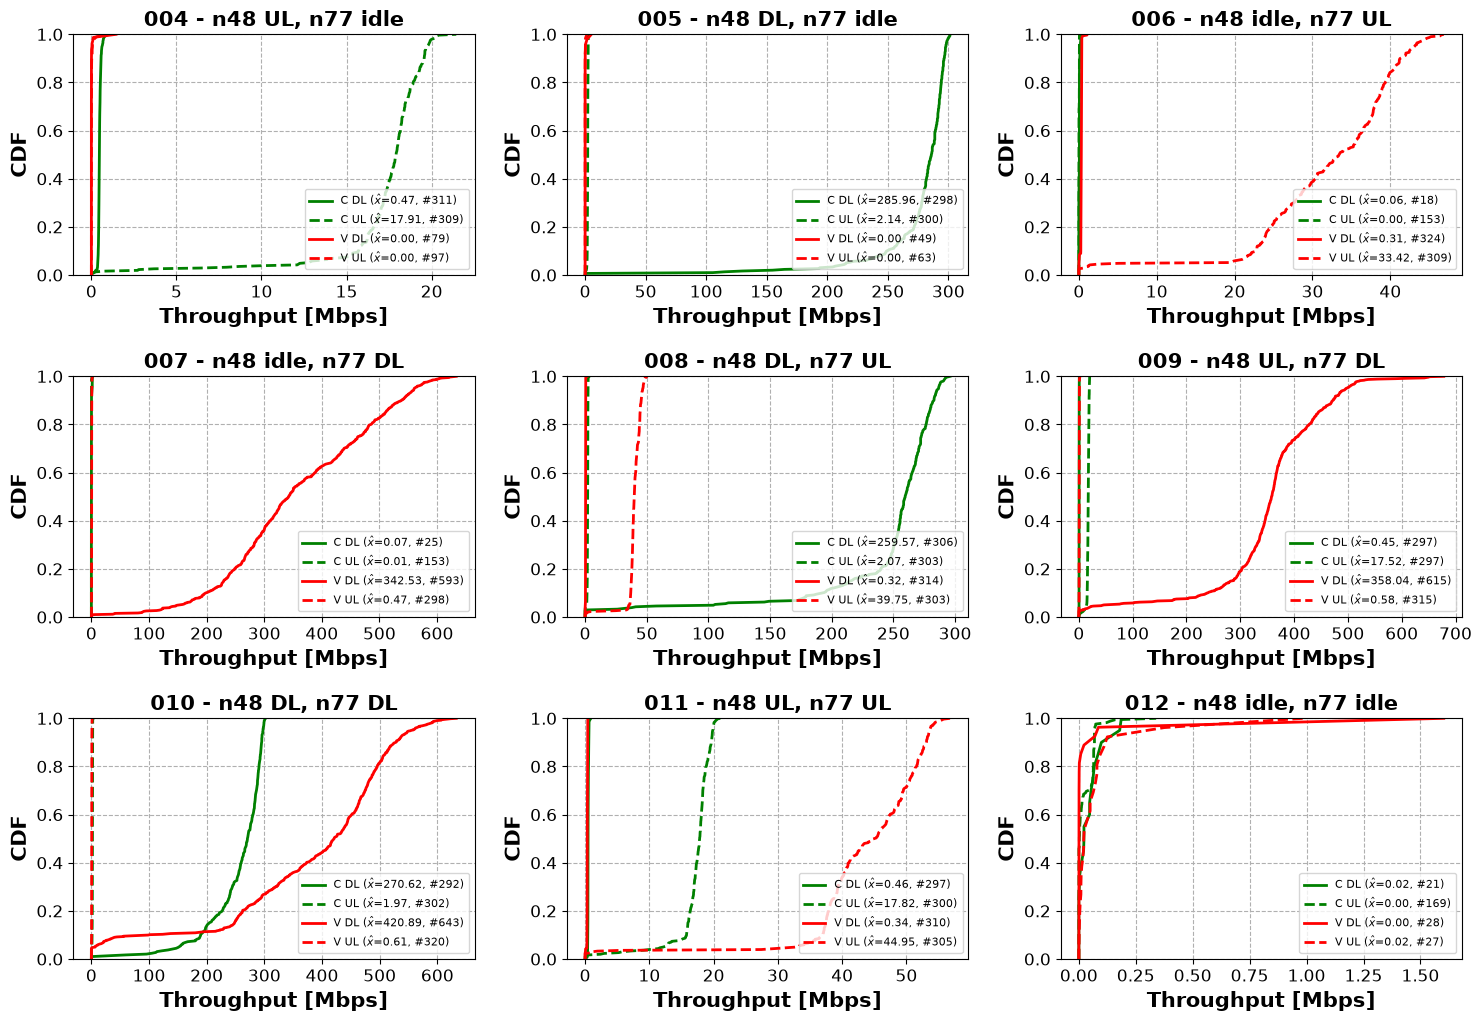

In [100]:
plt.rcParams["text.usetex"] = False

plot_titles = {
    '004': 'n48 UL, n77 idle',
    '005': 'n48 DL, n77 idle',
    '006': 'n48 idle, n77 UL',
    '007': 'n48 idle, n77 DL',
    '008': 'n48 DL, n77 UL',
    '009': 'n48 UL, n77 DL',
    '010': 'n48 DL, n77 DL',
    '011': 'n48 UL, n77 UL',
    '012': 'n48 idle, n77 idle'
}

fig, axes = plt.subplots(3, 3, figsize=(15, 10.5))
axes = axes.ravel()

for ax, (collection_number, plot_title) in zip(axes, plot_titles.items()):
    for prefix, color in [('C', 'green'), ('V', 'red')]:
        collection = f'{prefix}_{collection_number}'

        df_dl = nrPdsch.loc[
            nrPdsch['Collection'] == collection,
            '5G NR Net PDSCH Throughput'
        ].dropna().sort_values() / 1e3

        df_ul = nrPusch.loc[
            nrPusch['Collection'] == collection,
            '5G NR Net PUSCH Throughput'
        ].dropna().sort_values() / 1e3

        if df_dl.shape[0] > 0:
            ax.plot(
                df_dl, np.linspace(0, 1, df_dl.shape[0]),
                label=rf"{prefix} DL ($\hat{{x}}$={df_dl.median():.2f}, #{df_dl.shape[0]})",
                linewidth=2, linestyle="solid", color=color
            )

        if df_ul.shape[0] > 0:
            ax.plot(
                df_ul, np.linspace(0, 1, df_ul.shape[0]),
                label=rf"{prefix} UL ($\hat{{x}}$={df_ul.median():.2f}, #{df_ul.shape[0]})",
                linewidth=2, linestyle="dashed", color=color
            )

    ax.set_title(f"{collection_number} - {plot_title}", fontsize=15, fontweight="bold")
    ax.set_xlabel("Throughput [Mbps]", fontsize=15, fontweight="bold")
    ax.set_ylabel("CDF", fontsize=15, fontweight="bold")
    ax.set_ylim(0, 1)
    ax.yaxis.set_minor_locator(AutoLocator())
    ax.grid(True, linestyle="--", which="both", axis="both")
    ax.tick_params(axis="both", labelsize=12)
    ax.legend(fontsize=8, loc="lower right")

plt.tight_layout()
plt.show()

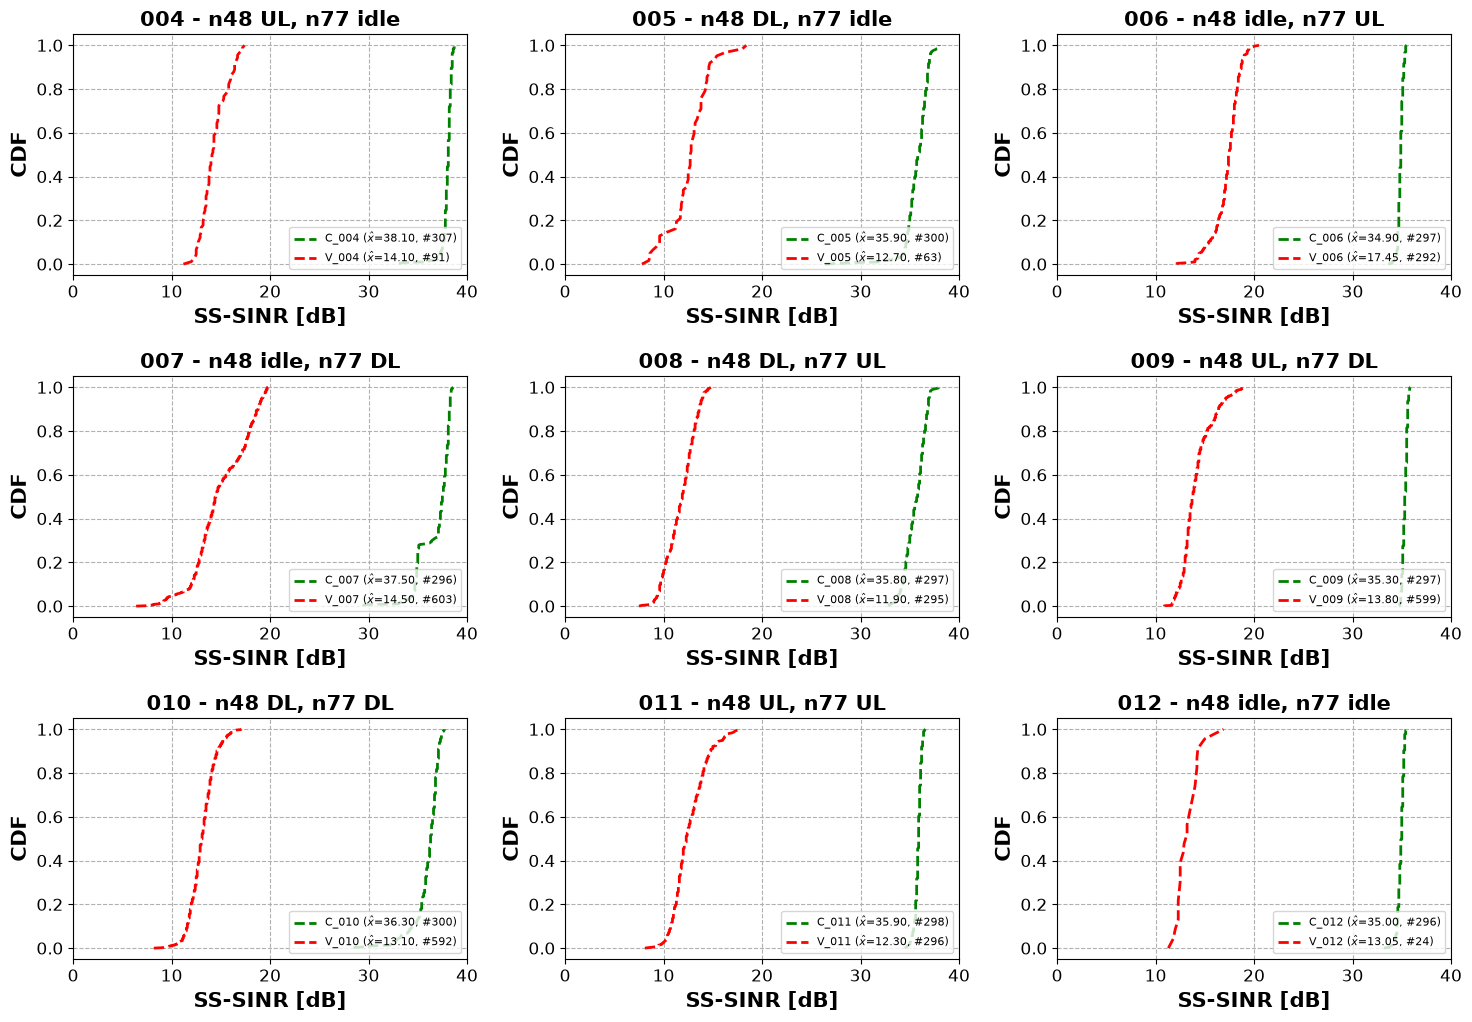

In [101]:
plt.rcParams["text.usetex"] = False

plot_titles = {
    '004': 'n48 UL, n77 idle',
    '005': 'n48 DL, n77 idle',
    '006': 'n48 idle, n77 UL',
    '007': 'n48 idle, n77 DL',
    '008': 'n48 DL, n77 UL',
    '009': 'n48 UL, n77 DL',
    '010': 'n48 DL, n77 DL',
    '011': 'n48 UL, n77 UL',
    '012': 'n48 idle, n77 idle'
}

fig, axes = plt.subplots(3, 3, figsize=(15, 10.5))
axes = axes.ravel()

for ax, (collection_number, plot_title) in zip(axes, plot_titles.items()):
    for prefix, color in [('C', 'green'), ('V', 'red')]:
        collection = f'{prefix}_{collection_number}'
        df_temp = nrRadio.loc[nrRadio['Collection'] == collection, 'SS-SINR'].dropna().sort_values()

        if df_temp.shape[0] == 0:
            continue

        ax.plot(
            df_temp, np.linspace(0, 1, df_temp.shape[0]),
            label=rf"{collection} ($\hat{{x}}$={df_temp.median():.2f}, #{df_temp.shape[0]})",
            linewidth=2, linestyle="dashed", color=color
        )

    ax.set_title(f"{collection_number} - {plot_title}", fontsize=15, fontweight="bold")
    ax.set_xlabel("SS-SINR [dB]", fontsize=15, fontweight="bold")
    ax.set_ylabel("CDF", fontsize=15, fontweight="bold")
    ax.set_xlim(0, 40)
    ax.yaxis.set_minor_locator(AutoLocator())
    ax.grid(True, linestyle="--", which="both", axis="both")
    ax.tick_params(axis="both", labelsize=12)
    ax.legend(fontsize=8, loc="lower right")

plt.tight_layout()
plt.show()

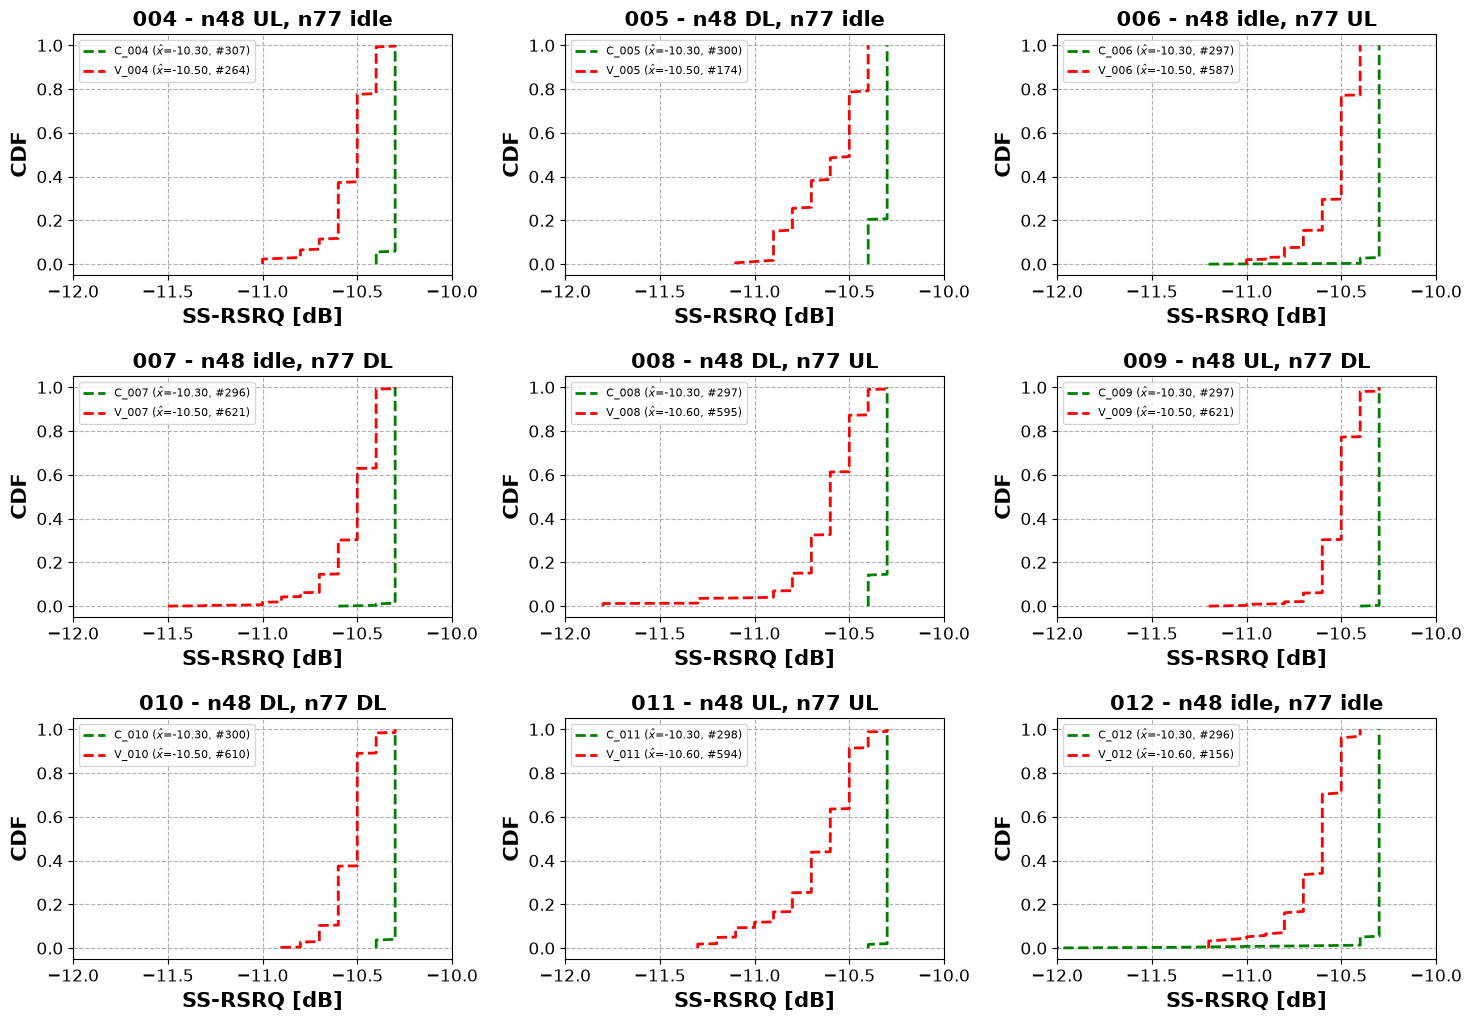

In [102]:
plt.rcParams["text.usetex"] = False

plot_titles = {
    '004': 'n48 UL, n77 idle',
    '005': 'n48 DL, n77 idle',
    '006': 'n48 idle, n77 UL',
    '007': 'n48 idle, n77 DL',
    '008': 'n48 DL, n77 UL',
    '009': 'n48 UL, n77 DL',
    '010': 'n48 DL, n77 DL',
    '011': 'n48 UL, n77 UL',
    '012': 'n48 idle, n77 idle'
}

fig, axes = plt.subplots(3, 3, figsize=(15, 10.5))
axes = axes.ravel()

for ax, (collection_number, plot_title) in zip(axes, plot_titles.items()):
    for prefix, color in [('C', 'green'), ('V', 'red')]:
        collection = f'{prefix}_{collection_number}'
        df_temp = nrRadio.loc[nrRadio['Collection'] == collection, 'SS-RSRQ'].dropna().sort_values()

        if df_temp.shape[0] == 0:
            continue

        ax.plot(
            df_temp, np.linspace(0, 1, df_temp.shape[0]),
            label=rf"{collection} ($\hat{{x}}$={df_temp.median():.2f}, #{df_temp.shape[0]})",
            linewidth=2, linestyle="dashed", color=color
        )

    ax.set_title(f"{collection_number} - {plot_title}", fontsize=15, fontweight="bold")
    ax.set_xlabel("SS-RSRQ [dB]", fontsize=15, fontweight="bold")
    ax.set_ylabel("CDF", fontsize=15, fontweight="bold")
    ax.set_xlim(-12, -10)
    ax.yaxis.set_minor_locator(AutoLocator())
    ax.grid(True, linestyle="--", which="both", axis="both")
    ax.tick_params(axis="both", labelsize=12)
    ax.legend(fontsize=8, loc="upper left")

plt.tight_layout()
plt.show()

# LocationB

In [103]:
collections = [f'{prefix}_{number:03d}' for prefix in ['C', 'V'] for number in range(13, 22)]
plot_geo_scatter_map(nrRadio[nrRadio['Collection'].isin(collections)].dropna(subset=['Latitude', 'Longitude', 'SS-RSRP']), value_col='SS-RSRP', title="Collection 013-021", colorbar_title="SS-RSRP", unit="dBm", value_range=[-120, -50])

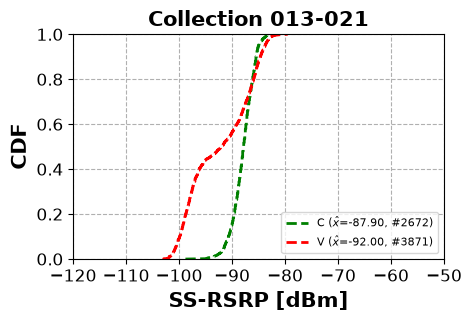

In [104]:
plt.rcParams["text.usetex"] = False

collection_numbers = [f'{number:03d}' for number in range(13, 22)]

fig, ax = plt.subplots(figsize=(5, 3.5))

for prefix, color in [('C', 'green'), ('V', 'red')]:
    collections = [f'{prefix}_{number}' for number in collection_numbers]
    df_temp = nrRadio.loc[nrRadio['Collection'].isin(collections), 'SS-RSRP'].dropna().sort_values()

    ax.plot(
        df_temp, np.linspace(0, 1, df_temp.shape[0]),
        label=rf"{prefix} ($\hat{{x}}$={df_temp.median():.2f}, #{df_temp.shape[0]})",
        linewidth=2, linestyle="dashed", color=color
    )

ax.set_title(f"Collection {collection_numbers[0]}-{collection_numbers[-1]}", fontsize=15, fontweight="bold")
ax.set_xlabel("SS-RSRP [dBm]", fontsize=15, fontweight="bold")
ax.set_ylabel("CDF", fontsize=15, fontweight="bold")
ax.set_xlim(-120, -50)
ax.set_ylim(0, 1)
ax.yaxis.set_minor_locator(AutoLocator())
ax.grid(True, linestyle="--", which="both", axis="both")
ax.tick_params(axis="both", labelsize=12)
ax.legend(fontsize=8, loc="lower right")

plt.tight_layout()
plt.show()

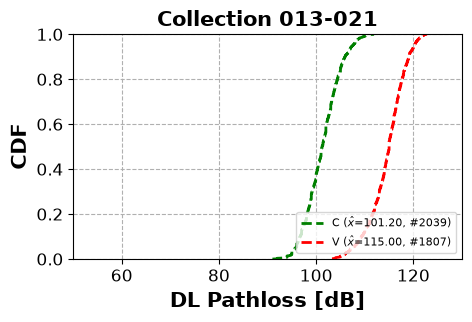

In [105]:
plt.rcParams["text.usetex"] = False

collection_numbers = [f'{number:03d}' for number in range(13, 22)]

fig, ax = plt.subplots(figsize=(5, 3.5))

for prefix, color in [('C', 'green'), ('V', 'red')]:
    collections = [f'{prefix}_{number}' for number in collection_numbers]
    df_temp = nrPusch.loc[nrPusch['Collection'].isin(collections), 'DL Pathloss'].dropna().sort_values()

    ax.plot(
        df_temp, np.linspace(0, 1, df_temp.shape[0]),
        label=rf"{prefix} ($\hat{{x}}$={df_temp.median():.2f}, #{df_temp.shape[0]})",
        linewidth=2, linestyle="dashed", color=color
    )

ax.set_title(f"Collection {collection_numbers[0]}-{collection_numbers[-1]}", fontsize=15, fontweight="bold")
ax.set_xlabel("DL Pathloss [dB]", fontsize=15, fontweight="bold")
ax.set_ylabel("CDF", fontsize=15, fontweight="bold")
ax.set_xlim(50, 130)
ax.set_ylim(0, 1)
ax.yaxis.set_minor_locator(AutoLocator())
ax.grid(True, linestyle="--", which="both", axis="both")
ax.tick_params(axis="both", labelsize=12)
ax.legend(fontsize=8, loc="lower right")

plt.tight_layout()
plt.show()

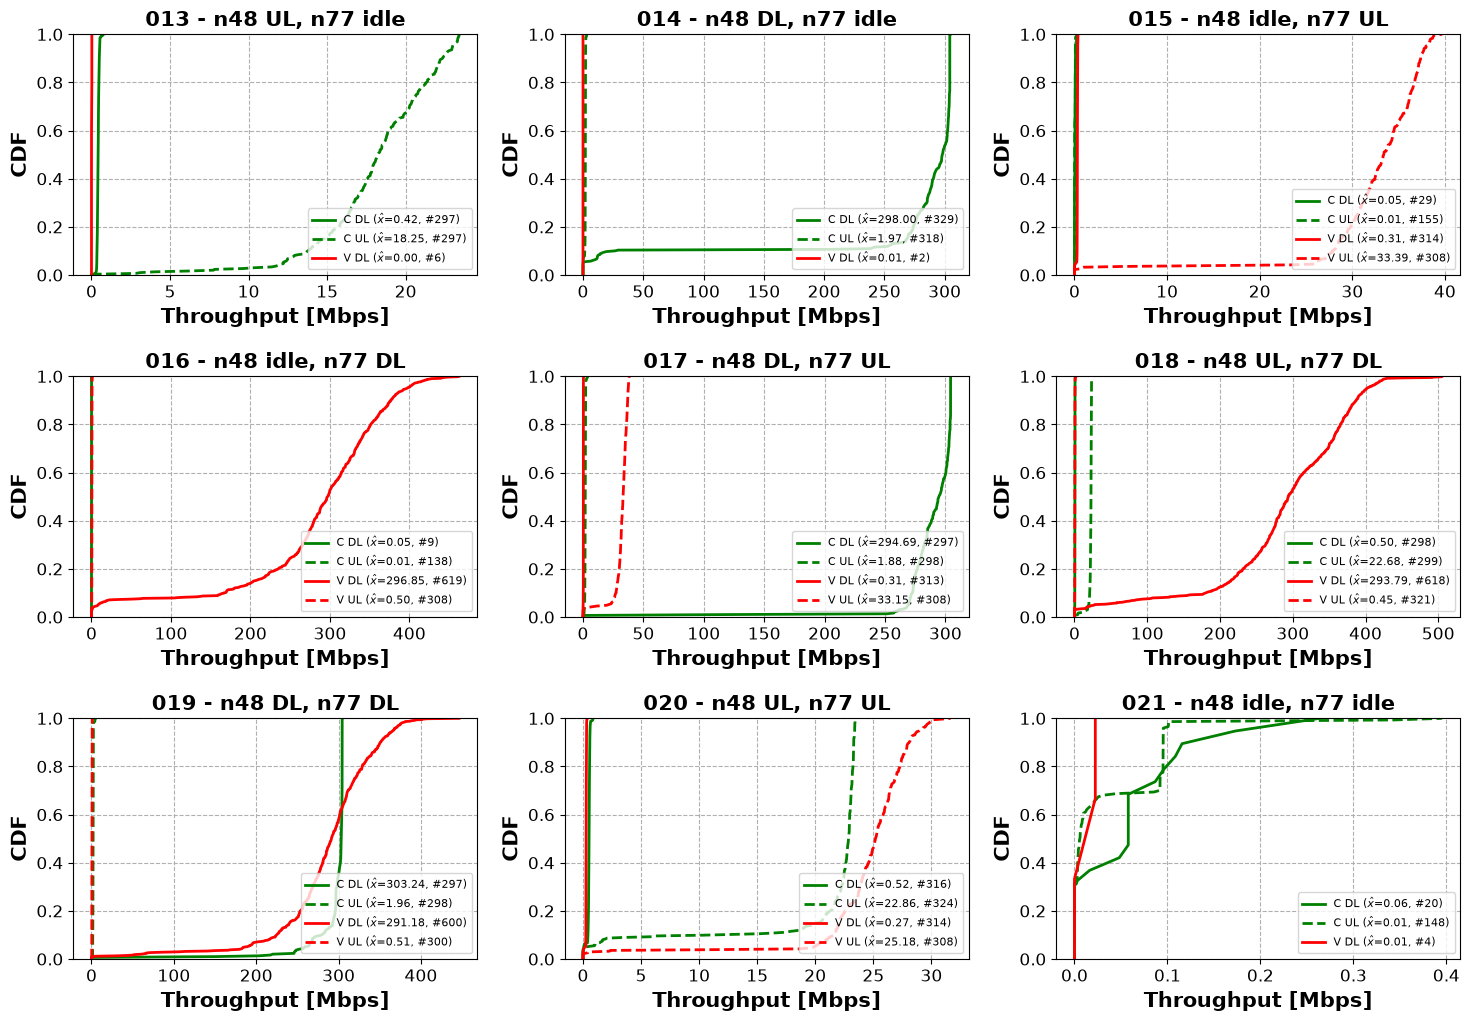

In [107]:
plt.rcParams["text.usetex"] = False

plot_titles = {
    '013': 'n48 UL, n77 idle',
    '014': 'n48 DL, n77 idle',
    '015': 'n48 idle, n77 UL',
    '016': 'n48 idle, n77 DL',
    '017': 'n48 DL, n77 UL',
    '018': 'n48 UL, n77 DL',
    '019': 'n48 DL, n77 DL',
    '020': 'n48 UL, n77 UL',
    '021': 'n48 idle, n77 idle'
}

fig, axes = plt.subplots(3, 3, figsize=(15, 10.5))
axes = axes.ravel()

for ax, (collection_number, plot_title) in zip(axes, plot_titles.items()):
    for prefix, color in [('C', 'green'), ('V', 'red')]:
        collection = f'{prefix}_{collection_number}'

        df_dl = nrPdsch.loc[
            nrPdsch['Collection'] == collection,
            '5G NR Net PDSCH Throughput'
        ].dropna().sort_values() / 1e3

        df_ul = nrPusch.loc[
            nrPusch['Collection'] == collection,
            '5G NR Net PUSCH Throughput'
        ].dropna().sort_values() / 1e3

        if df_dl.shape[0] > 0:
            ax.plot(
                df_dl, np.linspace(0, 1, df_dl.shape[0]),
                label=rf"{prefix} DL ($\hat{{x}}$={df_dl.median():.2f}, #{df_dl.shape[0]})",
                linewidth=2, linestyle="solid", color=color
            )

        if df_ul.shape[0] > 0:
            ax.plot(
                df_ul, np.linspace(0, 1, df_ul.shape[0]),
                label=rf"{prefix} UL ($\hat{{x}}$={df_ul.median():.2f}, #{df_ul.shape[0]})",
                linewidth=2, linestyle="dashed", color=color
            )

    ax.set_title(f"{collection_number} - {plot_title}", fontsize=15, fontweight="bold")
    ax.set_xlabel("Throughput [Mbps]", fontsize=15, fontweight="bold")
    ax.set_ylabel("CDF", fontsize=15, fontweight="bold")
    ax.set_ylim(0, 1)
    ax.yaxis.set_minor_locator(AutoLocator())
    ax.grid(True, linestyle="--", which="both", axis="both")
    ax.tick_params(axis="both", labelsize=12)
    ax.legend(fontsize=8, loc="lower right")

plt.tight_layout()
plt.show()

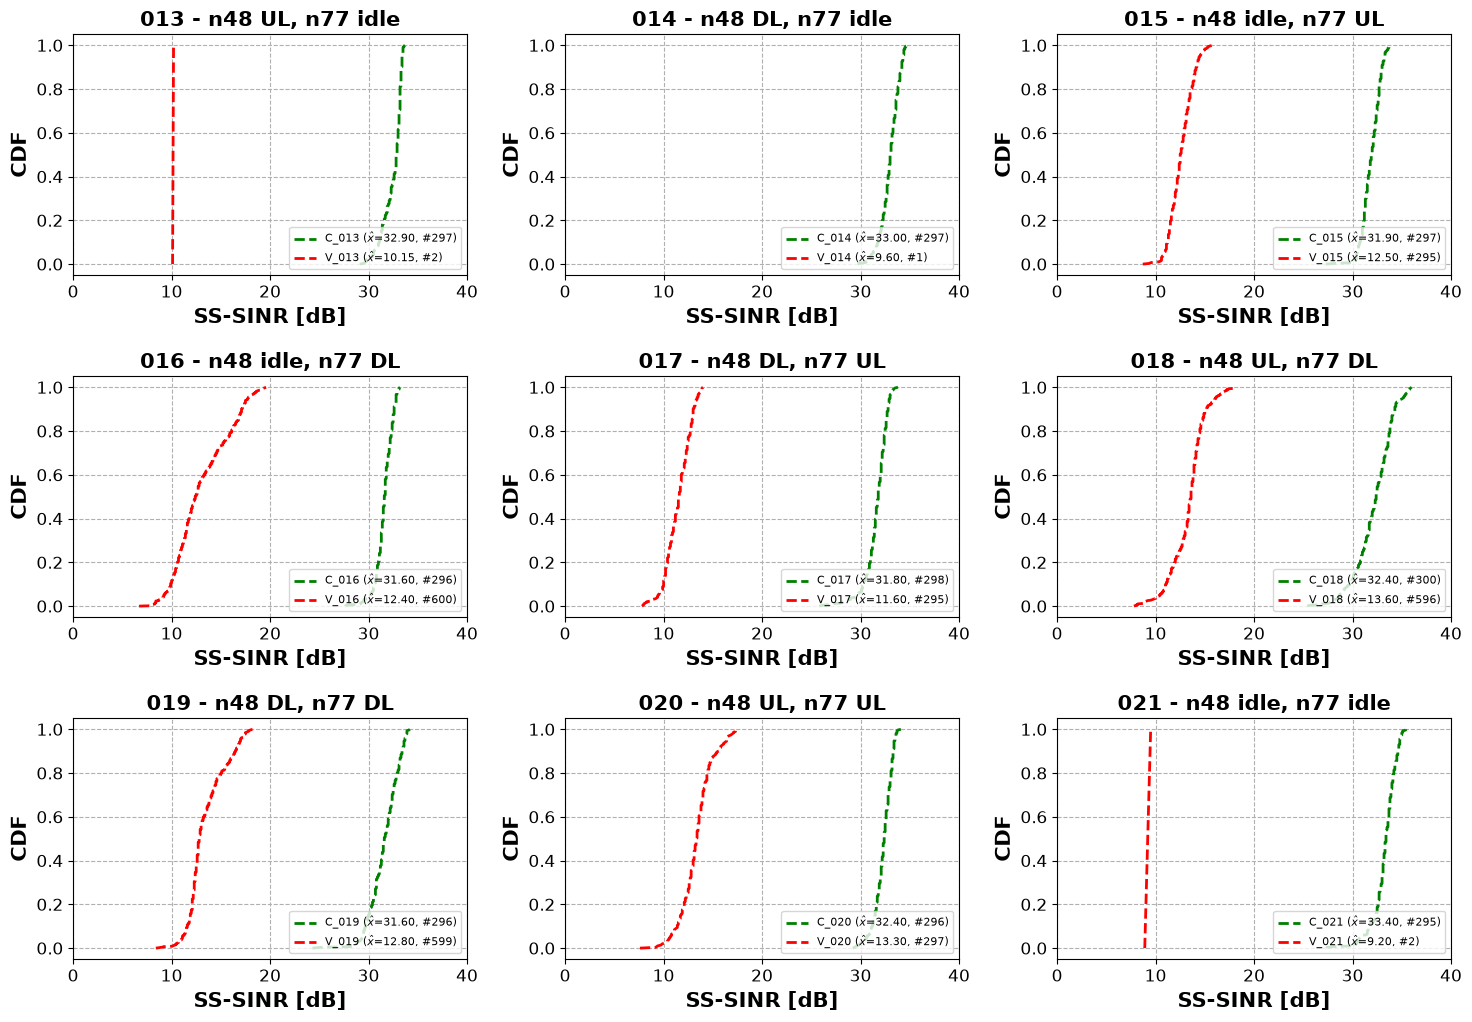

In [108]:
plt.rcParams["text.usetex"] = False

plot_titles = {
    '013': 'n48 UL, n77 idle',
    '014': 'n48 DL, n77 idle',
    '015': 'n48 idle, n77 UL',
    '016': 'n48 idle, n77 DL',
    '017': 'n48 DL, n77 UL',
    '018': 'n48 UL, n77 DL',
    '019': 'n48 DL, n77 DL',
    '020': 'n48 UL, n77 UL',
    '021': 'n48 idle, n77 idle'
}

fig, axes = plt.subplots(3, 3, figsize=(15, 10.5))
axes = axes.ravel()

for ax, (collection_number, plot_title) in zip(axes, plot_titles.items()):
    for prefix, color in [('C', 'green'), ('V', 'red')]:
        collection = f'{prefix}_{collection_number}'
        df_temp = nrRadio.loc[nrRadio['Collection'] == collection, 'SS-SINR'].dropna().sort_values()

        if df_temp.shape[0] == 0:
            continue

        ax.plot(
            df_temp, np.linspace(0, 1, df_temp.shape[0]),
            label=rf"{collection} ($\hat{{x}}$={df_temp.median():.2f}, #{df_temp.shape[0]})",
            linewidth=2, linestyle="dashed", color=color
        )

    ax.set_title(f"{collection_number} - {plot_title}", fontsize=15, fontweight="bold")
    ax.set_xlabel("SS-SINR [dB]", fontsize=15, fontweight="bold")
    ax.set_ylabel("CDF", fontsize=15, fontweight="bold")
    ax.set_xlim(0, 40)
    ax.yaxis.set_minor_locator(AutoLocator())
    ax.grid(True, linestyle="--", which="both", axis="both")
    ax.tick_params(axis="both", labelsize=12)
    ax.legend(fontsize=8, loc="lower right")

plt.tight_layout()
plt.show()

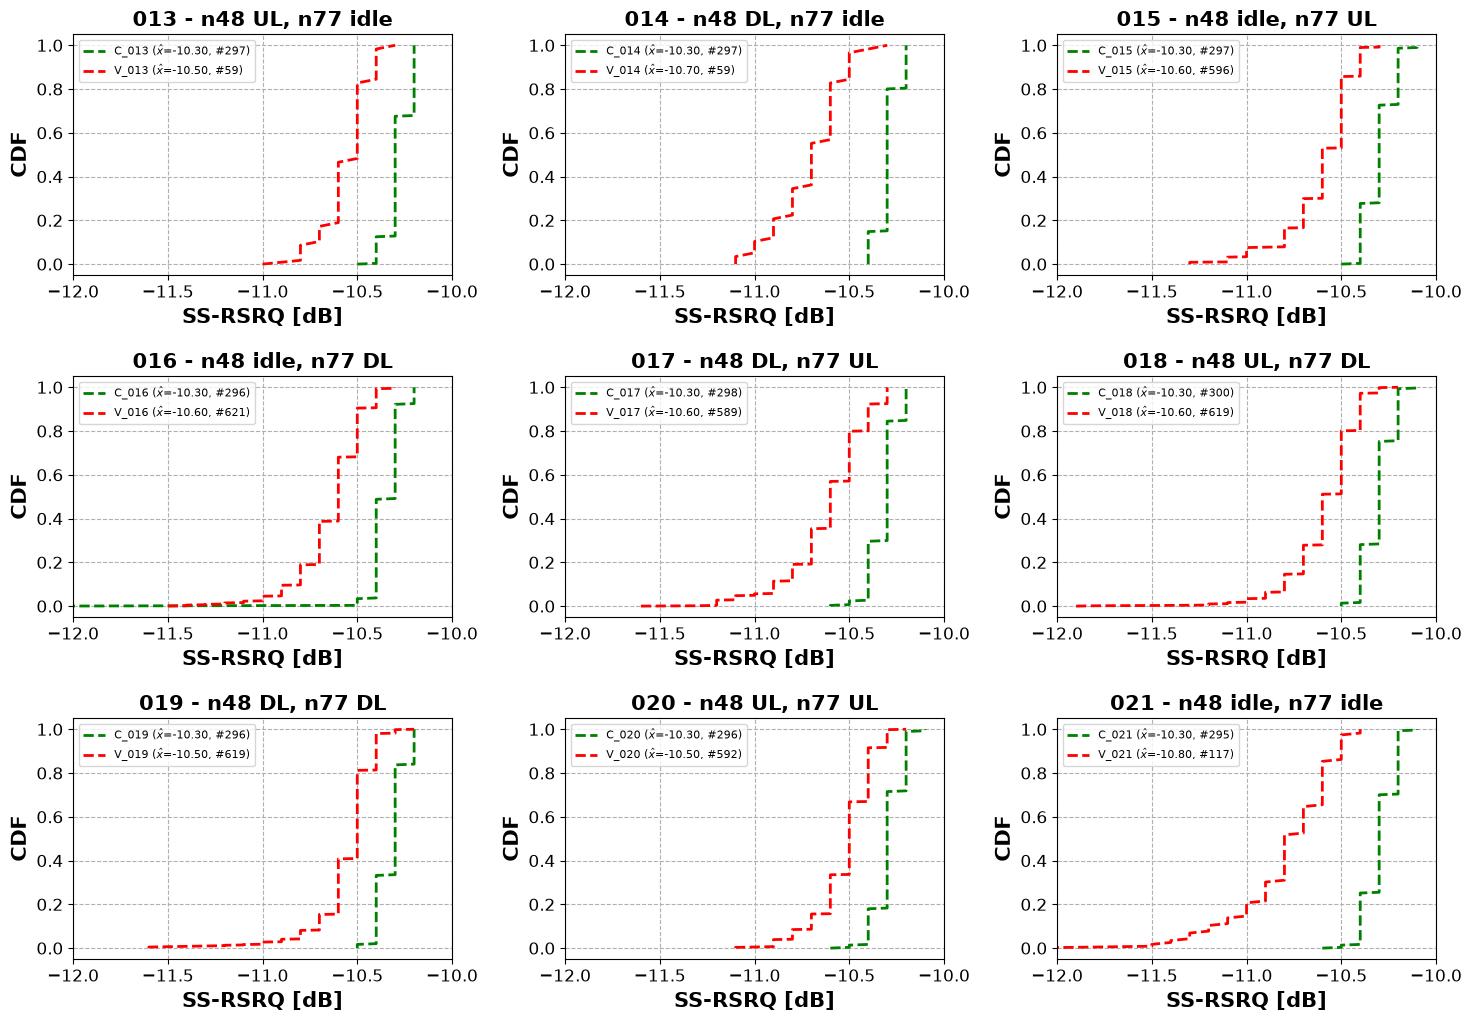

In [109]:
plt.rcParams["text.usetex"] = False

plot_titles = {
    '013': 'n48 UL, n77 idle',
    '014': 'n48 DL, n77 idle',
    '015': 'n48 idle, n77 UL',
    '016': 'n48 idle, n77 DL',
    '017': 'n48 DL, n77 UL',
    '018': 'n48 UL, n77 DL',
    '019': 'n48 DL, n77 DL',
    '020': 'n48 UL, n77 UL',
    '021': 'n48 idle, n77 idle'
}

fig, axes = plt.subplots(3, 3, figsize=(15, 10.5))
axes = axes.ravel()

for ax, (collection_number, plot_title) in zip(axes, plot_titles.items()):
    for prefix, color in [('C', 'green'), ('V', 'red')]:
        collection = f'{prefix}_{collection_number}'
        df_temp = nrRadio.loc[nrRadio['Collection'] == collection, 'SS-RSRQ'].dropna().sort_values()

        if df_temp.shape[0] == 0:
            continue

        ax.plot(
            df_temp, np.linspace(0, 1, df_temp.shape[0]),
            label=rf"{collection} ($\hat{{x}}$={df_temp.median():.2f}, #{df_temp.shape[0]})",
            linewidth=2, linestyle="dashed", color=color
        )

    ax.set_title(f"{collection_number} - {plot_title}", fontsize=15, fontweight="bold")
    ax.set_xlabel("SS-RSRQ [dB]", fontsize=15, fontweight="bold")
    ax.set_ylabel("CDF", fontsize=15, fontweight="bold")
    ax.set_xlim(-12, -10)
    ax.yaxis.set_minor_locator(AutoLocator())
    ax.grid(True, linestyle="--", which="both", axis="both")
    ax.tick_params(axis="both", labelsize=12)
    ax.legend(fontsize=8, loc="upper left")

plt.tight_layout()
plt.show()

# LocationC

In [110]:
collections = [f'{prefix}_{number:03d}' for prefix in ['C', 'V'] for number in range(22, 31)]
plot_geo_scatter_map(nrRadio[nrRadio['Collection'].isin(collections)].dropna(subset=['Latitude', 'Longitude', 'SS-RSRP']), value_col='SS-RSRP', title="Collection 022-030", colorbar_title="SS-RSRP", unit="dBm", value_range=[-120, -50])

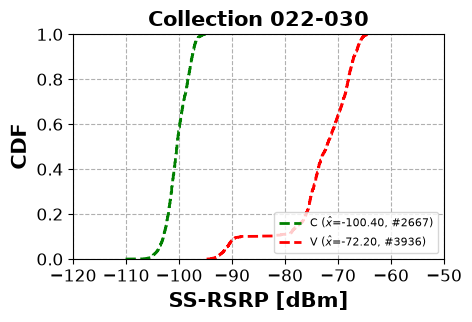

In [111]:
plt.rcParams["text.usetex"] = False

collection_numbers = [f'{number:03d}' for number in range(22, 31)]

fig, ax = plt.subplots(figsize=(5, 3.5))

for prefix, color in [('C', 'green'), ('V', 'red')]:
    collections = [f'{prefix}_{number}' for number in collection_numbers]
    df_temp = nrRadio.loc[nrRadio['Collection'].isin(collections), 'SS-RSRP'].dropna().sort_values()

    ax.plot(
        df_temp, np.linspace(0, 1, df_temp.shape[0]),
        label=rf"{prefix} ($\hat{{x}}$={df_temp.median():.2f}, #{df_temp.shape[0]})",
        linewidth=2, linestyle="dashed", color=color
    )

ax.set_title(f"Collection {collection_numbers[0]}-{collection_numbers[-1]}", fontsize=15, fontweight="bold")
ax.set_xlabel("SS-RSRP [dBm]", fontsize=15, fontweight="bold")
ax.set_ylabel("CDF", fontsize=15, fontweight="bold")
ax.set_xlim(-120, -50)
ax.set_ylim(0, 1)
ax.yaxis.set_minor_locator(AutoLocator())
ax.grid(True, linestyle="--", which="both", axis="both")
ax.tick_params(axis="both", labelsize=12)
ax.legend(fontsize=8, loc="lower right")

plt.tight_layout()
plt.show()

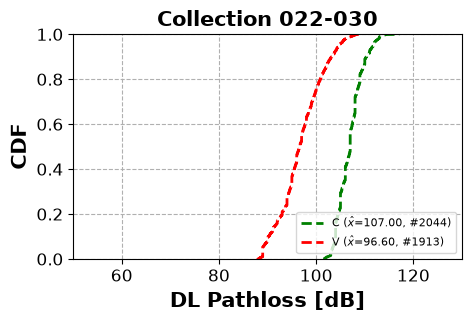

In [112]:
plt.rcParams["text.usetex"] = False

collection_numbers = [f'{number:03d}' for number in range(22, 31)]

fig, ax = plt.subplots(figsize=(5, 3.5))

for prefix, color in [('C', 'green'), ('V', 'red')]:
    collections = [f'{prefix}_{number}' for number in collection_numbers]
    df_temp = nrPusch.loc[nrPusch['Collection'].isin(collections), 'DL Pathloss'].dropna().sort_values()

    ax.plot(
        df_temp, np.linspace(0, 1, df_temp.shape[0]),
        label=rf"{prefix} ($\hat{{x}}$={df_temp.median():.2f}, #{df_temp.shape[0]})",
        linewidth=2, linestyle="dashed", color=color
    )

ax.set_title(f"Collection {collection_numbers[0]}-{collection_numbers[-1]}", fontsize=15, fontweight="bold")
ax.set_xlabel("DL Pathloss [dB]", fontsize=15, fontweight="bold")
ax.set_ylabel("CDF", fontsize=15, fontweight="bold")
ax.set_xlim(50, 130)
ax.set_ylim(0, 1)
ax.yaxis.set_minor_locator(AutoLocator())
ax.grid(True, linestyle="--", which="both", axis="both")
ax.tick_params(axis="both", labelsize=12)
ax.legend(fontsize=8, loc="lower right")

plt.tight_layout()
plt.show()

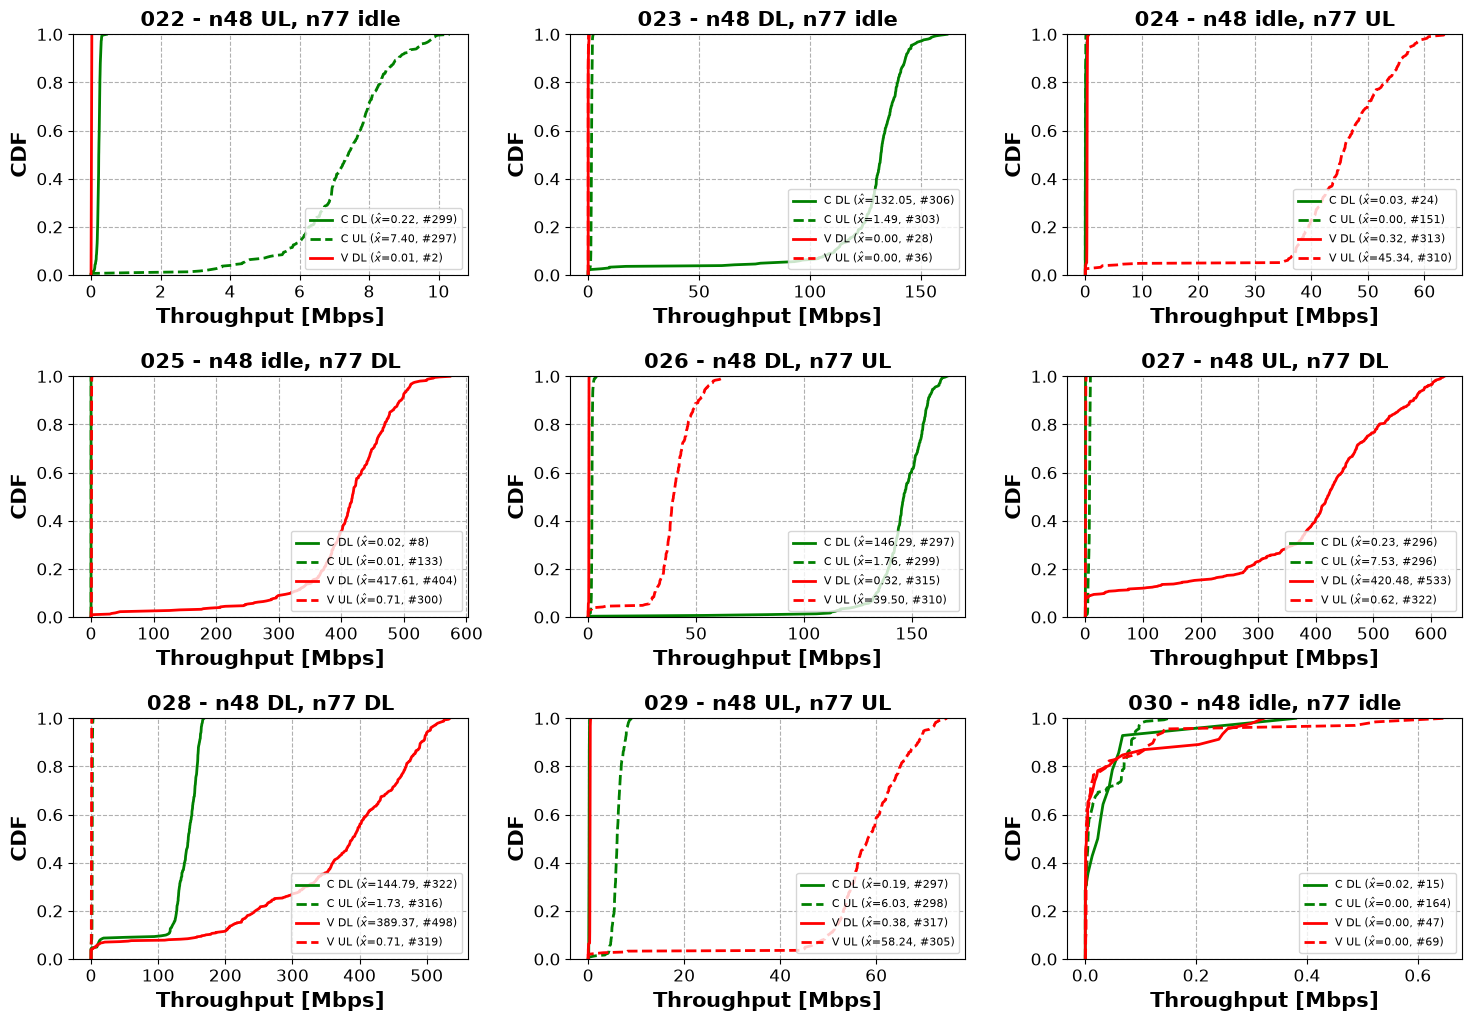

In [113]:
plt.rcParams["text.usetex"] = False

plot_titles = {
    '022': 'n48 UL, n77 idle',
    '023': 'n48 DL, n77 idle',
    '024': 'n48 idle, n77 UL',
    '025': 'n48 idle, n77 DL',
    '026': 'n48 DL, n77 UL',
    '027': 'n48 UL, n77 DL',
    '028': 'n48 DL, n77 DL',
    '029': 'n48 UL, n77 UL',
    '030': 'n48 idle, n77 idle'
}

fig, axes = plt.subplots(3, 3, figsize=(15, 10.5))
axes = axes.ravel()

for ax, (collection_number, plot_title) in zip(axes, plot_titles.items()):
    for prefix, color in [('C', 'green'), ('V', 'red')]:
        collection = f'{prefix}_{collection_number}'

        df_dl = nrPdsch.loc[
            nrPdsch['Collection'] == collection,
            '5G NR Net PDSCH Throughput'
        ].dropna().sort_values() / 1e3

        df_ul = nrPusch.loc[
            nrPusch['Collection'] == collection,
            '5G NR Net PUSCH Throughput'
        ].dropna().sort_values() / 1e3

        if df_dl.shape[0] > 0:
            ax.plot(
                df_dl, np.linspace(0, 1, df_dl.shape[0]),
                label=rf"{prefix} DL ($\hat{{x}}$={df_dl.median():.2f}, #{df_dl.shape[0]})",
                linewidth=2, linestyle="solid", color=color
            )

        if df_ul.shape[0] > 0:
            ax.plot(
                df_ul, np.linspace(0, 1, df_ul.shape[0]),
                label=rf"{prefix} UL ($\hat{{x}}$={df_ul.median():.2f}, #{df_ul.shape[0]})",
                linewidth=2, linestyle="dashed", color=color
            )

    ax.set_title(f"{collection_number} - {plot_title}", fontsize=15, fontweight="bold")
    ax.set_xlabel("Throughput [Mbps]", fontsize=15, fontweight="bold")
    ax.set_ylabel("CDF", fontsize=15, fontweight="bold")
    ax.set_ylim(0, 1)
    ax.yaxis.set_minor_locator(AutoLocator())
    ax.grid(True, linestyle="--", which="both", axis="both")
    ax.tick_params(axis="both", labelsize=12)
    ax.legend(fontsize=8, loc="lower right")

plt.tight_layout()
plt.show()

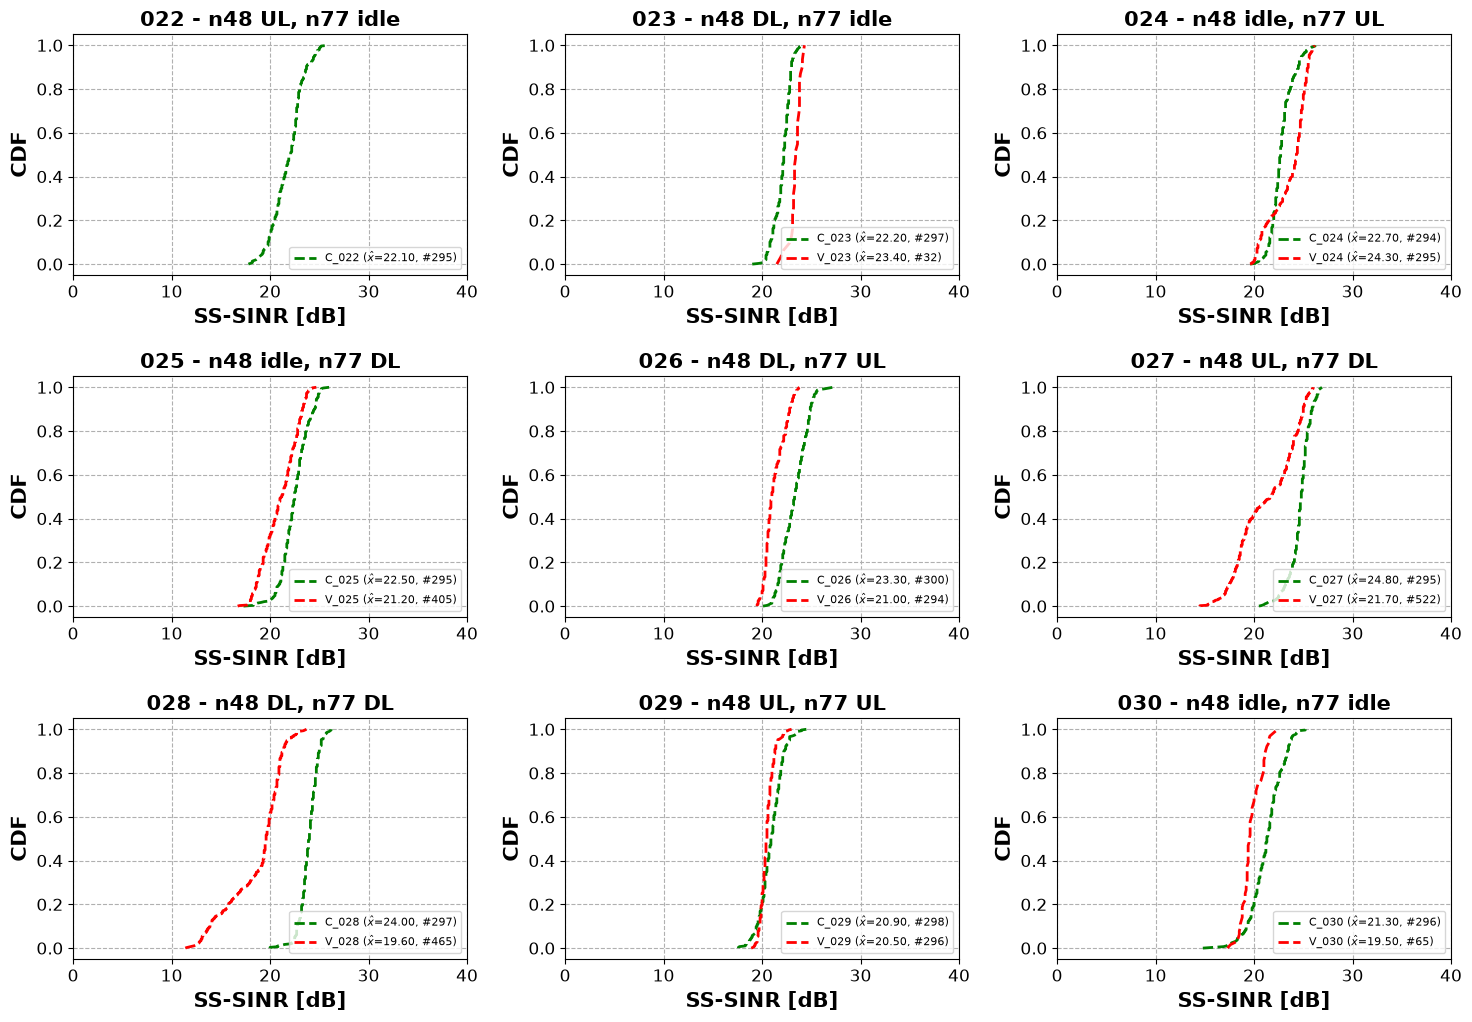

In [114]:
plt.rcParams["text.usetex"] = False

plot_titles = {
    '022': 'n48 UL, n77 idle',
    '023': 'n48 DL, n77 idle',
    '024': 'n48 idle, n77 UL',
    '025': 'n48 idle, n77 DL',
    '026': 'n48 DL, n77 UL',
    '027': 'n48 UL, n77 DL',
    '028': 'n48 DL, n77 DL',
    '029': 'n48 UL, n77 UL',
    '030': 'n48 idle, n77 idle'
}

fig, axes = plt.subplots(3, 3, figsize=(15, 10.5))
axes = axes.ravel()

for ax, (collection_number, plot_title) in zip(axes, plot_titles.items()):
    for prefix, color in [('C', 'green'), ('V', 'red')]:
        collection = f'{prefix}_{collection_number}'
        df_temp = nrRadio.loc[nrRadio['Collection'] == collection, 'SS-SINR'].dropna().sort_values()

        if df_temp.shape[0] == 0:
            continue

        ax.plot(
            df_temp, np.linspace(0, 1, df_temp.shape[0]),
            label=rf"{collection} ($\hat{{x}}$={df_temp.median():.2f}, #{df_temp.shape[0]})",
            linewidth=2, linestyle="dashed", color=color
        )

    ax.set_title(f"{collection_number} - {plot_title}", fontsize=15, fontweight="bold")
    ax.set_xlabel("SS-SINR [dB]", fontsize=15, fontweight="bold")
    ax.set_ylabel("CDF", fontsize=15, fontweight="bold")
    ax.set_xlim(0, 40)
    ax.yaxis.set_minor_locator(AutoLocator())
    ax.grid(True, linestyle="--", which="both", axis="both")
    ax.tick_params(axis="both", labelsize=12)
    ax.legend(fontsize=8, loc="lower right")

plt.tight_layout()
plt.show()

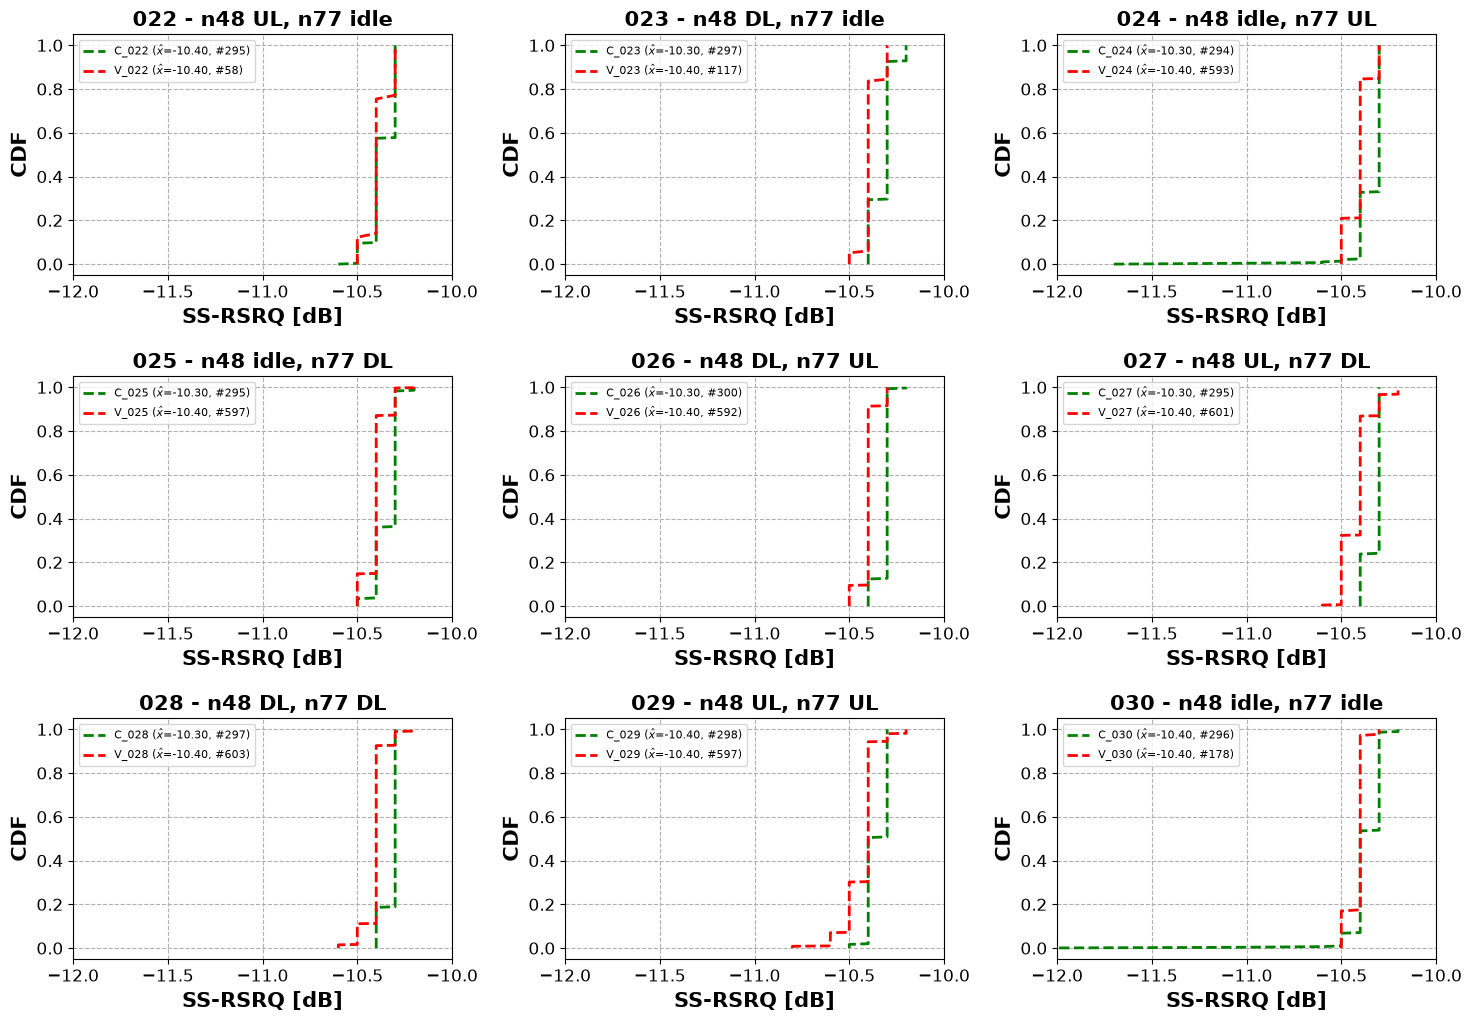

In [115]:
plt.rcParams["text.usetex"] = False

plot_titles = {
    '022': 'n48 UL, n77 idle',
    '023': 'n48 DL, n77 idle',
    '024': 'n48 idle, n77 UL',
    '025': 'n48 idle, n77 DL',
    '026': 'n48 DL, n77 UL',
    '027': 'n48 UL, n77 DL',
    '028': 'n48 DL, n77 DL',
    '029': 'n48 UL, n77 UL',
    '030': 'n48 idle, n77 idle'
}

fig, axes = plt.subplots(3, 3, figsize=(15, 10.5))
axes = axes.ravel()

for ax, (collection_number, plot_title) in zip(axes, plot_titles.items()):
    for prefix, color in [('C', 'green'), ('V', 'red')]:
        collection = f'{prefix}_{collection_number}'
        df_temp = nrRadio.loc[nrRadio['Collection'] == collection, 'SS-RSRQ'].dropna().sort_values()

        if df_temp.shape[0] == 0:
            continue

        ax.plot(
            df_temp, np.linspace(0, 1, df_temp.shape[0]),
            label=rf"{collection} ($\hat{{x}}$={df_temp.median():.2f}, #{df_temp.shape[0]})",
            linewidth=2, linestyle="dashed", color=color
        )

    ax.set_title(f"{collection_number} - {plot_title}", fontsize=15, fontweight="bold")
    ax.set_xlabel("SS-RSRQ [dB]", fontsize=15, fontweight="bold")
    ax.set_ylabel("CDF", fontsize=15, fontweight="bold")
    ax.set_xlim(-12, -10)
    ax.yaxis.set_minor_locator(AutoLocator())
    ax.grid(True, linestyle="--", which="both", axis="both")
    ax.tick_params(axis="both", labelsize=12)
    ax.legend(fontsize=8, loc="upper left")

plt.tight_layout()
plt.show()

# LocationD

In [116]:
collections = [f'{prefix}_{number:03d}' for prefix in ['C', 'V'] for number in range(31, 40)]
plot_geo_scatter_map(nrRadio[nrRadio['Collection'].isin(collections)].dropna(subset=['Latitude', 'Longitude', 'SS-RSRP']), value_col='SS-RSRP', title="Collection 022-030", colorbar_title="SS-RSRP", unit="dBm", value_range=[-120, -50])

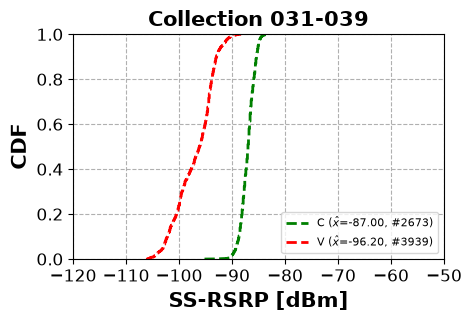

In [117]:
plt.rcParams["text.usetex"] = False

collection_numbers = [f'{number:03d}' for number in range(31, 40)]

fig, ax = plt.subplots(figsize=(5, 3.5))

for prefix, color in [('C', 'green'), ('V', 'red')]:
    collections = [f'{prefix}_{number}' for number in collection_numbers]
    df_temp = nrRadio.loc[nrRadio['Collection'].isin(collections), 'SS-RSRP'].dropna().sort_values()

    ax.plot(
        df_temp, np.linspace(0, 1, df_temp.shape[0]),
        label=rf"{prefix} ($\hat{{x}}$={df_temp.median():.2f}, #{df_temp.shape[0]})",
        linewidth=2, linestyle="dashed", color=color
    )

ax.set_title(f"Collection {collection_numbers[0]}-{collection_numbers[-1]}", fontsize=15, fontweight="bold")
ax.set_xlabel("SS-RSRP [dBm]", fontsize=15, fontweight="bold")
ax.set_ylabel("CDF", fontsize=15, fontweight="bold")
ax.set_xlim(-120, -50)
ax.set_ylim(0, 1)
ax.yaxis.set_minor_locator(AutoLocator())
ax.grid(True, linestyle="--", which="both", axis="both")
ax.tick_params(axis="both", labelsize=12)
ax.legend(fontsize=8, loc="lower right")

plt.tight_layout()
plt.show()

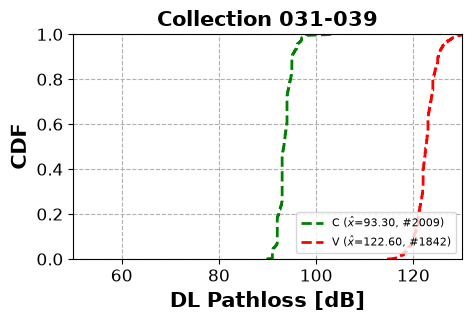

In [127]:
plt.rcParams["text.usetex"] = False

collection_numbers = [f'{number:03d}' for number in range(31, 40)]

fig, ax = plt.subplots(figsize=(5, 3.5))

for prefix, color in [('C', 'green'), ('V', 'red')]:
    collections = [f'{prefix}_{number}' for number in collection_numbers]
    df_temp = nrPusch.loc[nrPusch['Collection'].isin(collections), 'DL Pathloss'].dropna().sort_values()

    ax.plot(
        df_temp, np.linspace(0, 1, df_temp.shape[0]),
        label=rf"{prefix} ($\hat{{x}}$={df_temp.median():.2f}, #{df_temp.shape[0]})",
        linewidth=2, linestyle="dashed", color=color
    )

ax.set_title(f"Collection {collection_numbers[0]}-{collection_numbers[-1]}", fontsize=15, fontweight="bold")
ax.set_xlabel("DL Pathloss [dB]", fontsize=15, fontweight="bold")
ax.set_ylabel("CDF", fontsize=15, fontweight="bold")
ax.set_xlim(50, 130)
ax.set_ylim(0, 1)
ax.yaxis.set_minor_locator(AutoLocator())
ax.grid(True, linestyle="--", which="both", axis="both")
ax.tick_params(axis="both", labelsize=12)
ax.legend(fontsize=8, loc="lower right")

plt.tight_layout()
plt.show()

# LocationE

In [118]:
collections = [f'{prefix}_{number:03d}' for prefix in ['C', 'V'] for number in range(40, 50)]
plot_geo_scatter_map(nrRadio[nrRadio['Collection'].isin(collections)].dropna(subset=['Latitude', 'Longitude', 'SS-RSRP']), value_col='SS-RSRP', title="Collection 022-030", colorbar_title="SS-RSRP", unit="dBm", value_range=[-120, -50])

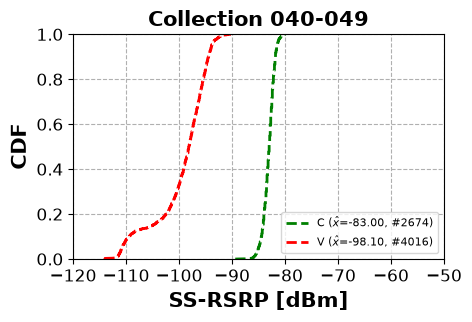

In [119]:
plt.rcParams["text.usetex"] = False

collection_numbers = [f'{number:03d}' for number in range(40, 50)]

fig, ax = plt.subplots(figsize=(5, 3.5))

for prefix, color in [('C', 'green'), ('V', 'red')]:
    collections = [f'{prefix}_{number}' for number in collection_numbers]
    df_temp = nrRadio.loc[nrRadio['Collection'].isin(collections), 'SS-RSRP'].dropna().sort_values()

    ax.plot(
        df_temp, np.linspace(0, 1, df_temp.shape[0]),
        label=rf"{prefix} ($\hat{{x}}$={df_temp.median():.2f}, #{df_temp.shape[0]})",
        linewidth=2, linestyle="dashed", color=color
    )

ax.set_title(f"Collection {collection_numbers[0]}-{collection_numbers[-1]}", fontsize=15, fontweight="bold")
ax.set_xlabel("SS-RSRP [dBm]", fontsize=15, fontweight="bold")
ax.set_ylabel("CDF", fontsize=15, fontweight="bold")
ax.set_xlim(-120, -50)
ax.set_ylim(0, 1)
ax.yaxis.set_minor_locator(AutoLocator())
ax.grid(True, linestyle="--", which="both", axis="both")
ax.tick_params(axis="both", labelsize=12)
ax.legend(fontsize=8, loc="lower right")

plt.tight_layout()
plt.show()

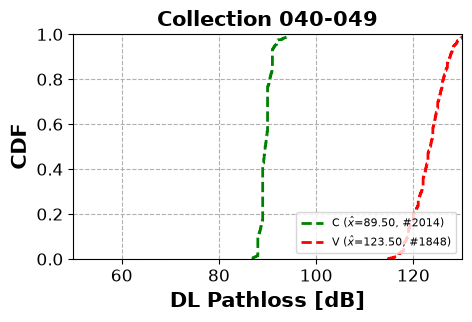

In [128]:
plt.rcParams["text.usetex"] = False

collection_numbers = [f'{number:03d}' for number in range(40, 50)]

fig, ax = plt.subplots(figsize=(5, 3.5))

for prefix, color in [('C', 'green'), ('V', 'red')]:
    collections = [f'{prefix}_{number}' for number in collection_numbers]
    df_temp = nrPusch.loc[nrPusch['Collection'].isin(collections), 'DL Pathloss'].dropna().sort_values()

    ax.plot(
        df_temp, np.linspace(0, 1, df_temp.shape[0]),
        label=rf"{prefix} ($\hat{{x}}$={df_temp.median():.2f}, #{df_temp.shape[0]})",
        linewidth=2, linestyle="dashed", color=color
    )

ax.set_title(f"Collection {collection_numbers[0]}-{collection_numbers[-1]}", fontsize=15, fontweight="bold")
ax.set_xlabel("DL Pathloss [dB]", fontsize=15, fontweight="bold")
ax.set_ylabel("CDF", fontsize=15, fontweight="bold")
ax.set_xlim(50, 130)
ax.set_ylim(0, 1)
ax.yaxis.set_minor_locator(AutoLocator())
ax.grid(True, linestyle="--", which="both", axis="both")
ax.tick_params(axis="both", labelsize=12)
ax.legend(fontsize=8, loc="lower right")

plt.tight_layout()
plt.show()